In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.utils import to_categorical
from sklearn import datasets

I0000 00:00:1790978405.368178    4344 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1790978405.404953    4344 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1790978406.521564    4344 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
iris = datasets.load_iris()
X = iris.data
target = iris.target
Y = to_categorical(target).astype("uint8")
# 0 => [1 0 0]
# 1 => [0 1 0]
# 2 => [0 0 1]

In [3]:
idx = 0
print(X[idx])
print(target[idx])
print(Y[idx])

[5.1 3.5 1.4 0.2]
0
[1 0 0]


In [4]:
#Topología: 4 x 3 x 3 x 3 x 3  (tres capas ocultas + salida)
model = keras.Sequential(
  [
    layers.Dense(3, activation="sigmoid", name="layer1", input_shape=(4,)),
    layers.Dense(3, activation="sigmoid", name="layer2"),   # capa oculta nueva
    layers.Dense(3, activation="sigmoid", name="layer3"),   # capa oculta nueva
    layers.Dense(3, activation="sigmoid", name="layer4"),   # capa de salida
  ]
)

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ layer1 (Dense)                  │ (None, 3)              │            15 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer2 (Dense)                  │ (None, 3)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer3 (Dense)                  │ (None, 3)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer4 (Dense)                  │ (None, 3)              │            12 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51 (204.00 B)

 Trainable params: 51 (204.00 B)

 Non-trainable params: 0 (0.00 B)

In [5]:
y = model(X)
print(y[149])

tf.Tensor([0.36045274 0.5369816  0.5168292 ], shape=(3,), dtype=float32)


In [6]:
optimizer=tf.keras.optimizers.SGD(learning_rate=0.03)
loss=tf.keras.losses.MeanSquaredError()

model.compile(optimizer, loss)
history = model.fit(X, Y, epochs=500)

Epoch 1/500


1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step - loss: 0.2456

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.2473  


Epoch 2/500


1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.2573

...

1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.2223

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.2223 


Epoch 500/500


1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.2221

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2223 


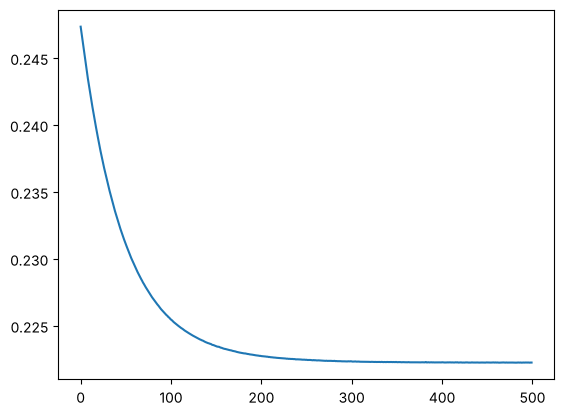

In [7]:
plt.plot(history.history['loss'])
plt.show()

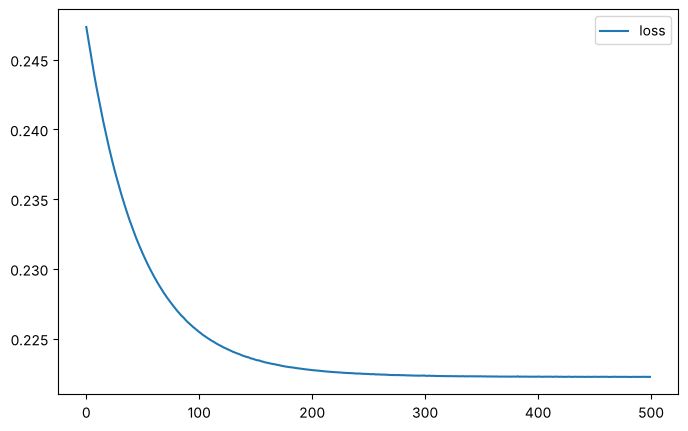

In [8]:
pd.DataFrame(history.history).plot(figsize=(8,5))
plt.show()

In [9]:
model.predict(np.array([[3,3,1,1]]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


array([[0.33365414, 0.33560404, 0.3354304 ]], dtype=float32)